# Sound Classification


In [252]:
#Import Libraries
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [254]:
paths = []
labels = []
for dirname, _, filenames in os.walk('C:/Users/Lester/Downloads/Emotions'):
    for filename in filenames:
        paths.append(os.path.join(dirname, filename))
        label = filename.split('_')[-1]
        label = label.split('.')[0]
        labels.append(label.lower())
    if len(paths) == 2800:
        break

In [255]:
len(paths)

70

In [256]:
paths[:5]

['C:/Users/Lester/Downloads/Emotions\\Angry\\YAF_rush_angry.wav',
 'C:/Users/Lester/Downloads/Emotions\\Angry\\YAF_said_angry.wav',
 'C:/Users/Lester/Downloads/Emotions\\Angry\\YAF_sail_angry.wav',
 'C:/Users/Lester/Downloads/Emotions\\Angry\\YAF_search_angry.wav',
 'C:/Users/Lester/Downloads/Emotions\\Angry\\YAF_seize_angry.wav']

In [257]:
labels[:5]

['angry', 'angry', 'angry', 'angry', 'angry']

In [258]:
## Create a dataframe
df = pd.DataFrame()
df['speech'] = paths
df['label'] = labels
df.head()

,speech,label
0,C:/Users/Lester/Downloads/Emotions\Angry\YAF_r...,angry
1,C:/Users/Lester/Downloads/Emotions\Angry\YAF_s...,angry
2,C:/Users/Lester/Downloads/Emotions\Angry\YAF_s...,angry
3,C:/Users/Lester/Downloads/Emotions\Angry\YAF_s...,angry
4,C:/Users/Lester/Downloads/Emotions\Angry\YAF_s...,angry


In [259]:
df['label'].value_counts()

angry        10
disgust      10
fear         10
happy        10
neutral      10
sad          10
surprised    10
Name: label, dtype: int64

# Explaratory Data Analysis

In this section we will visualize the different emotions based from our created dataset which is 10 files per emotion.

<Axes: xlabel='label', ylabel='count'>

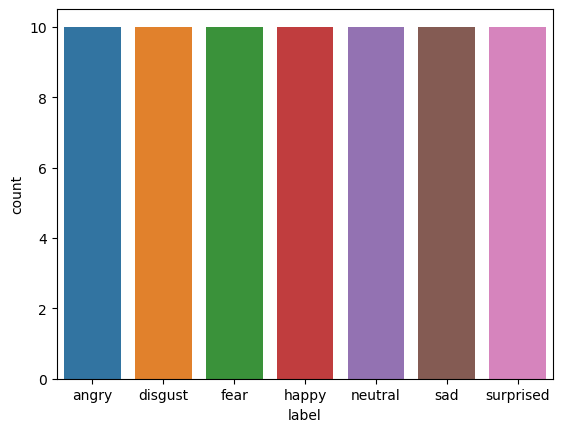

In [262]:
sns.countplot(data=df, x='label')

# Audio Visualization
Here we will visualize each emotion to determine their wavelengths using a waveplot and a spectogram.

In [264]:
def waveplot(data, sr, emotion):
    plt.figure(figsize=(10,4))
    plt.title(emotion, size=20)
    librosa.display.waveshow(data, sr=sr)
    plt.show()
    
def spectogram(data, sr, emotion):
    x = librosa.stft(data)
    xdb = librosa.amplitude_to_db(abs(x))
    plt.figure(figsize=(11,4))
    plt.title(emotion, size=20)
    librosa.display.specshow(xdb, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar()

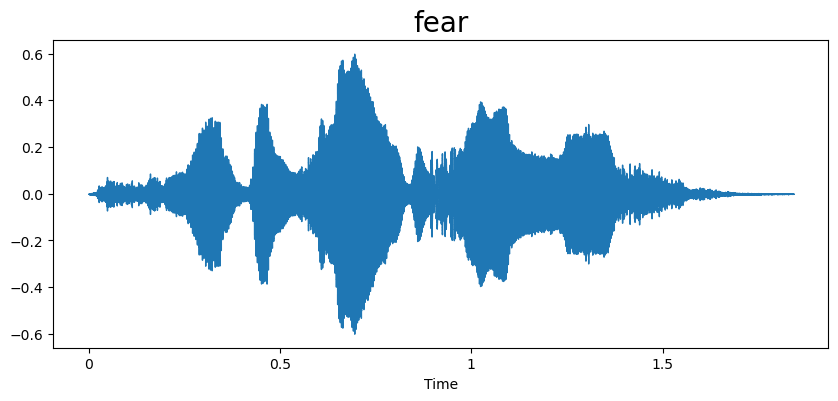

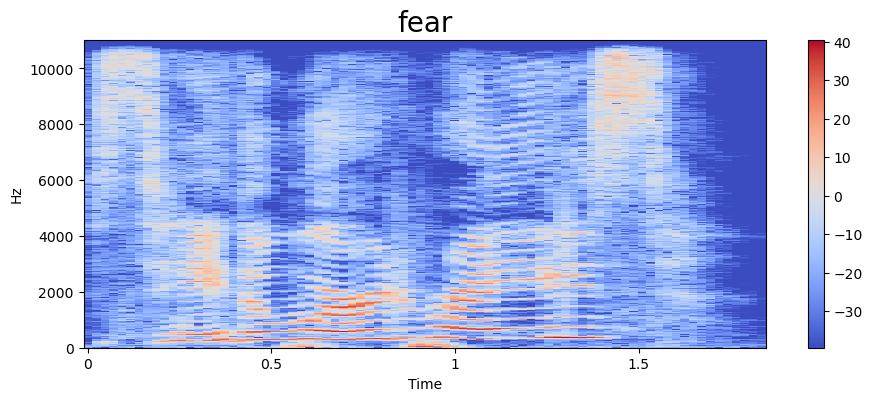

In [265]:
emotion = 'fear'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

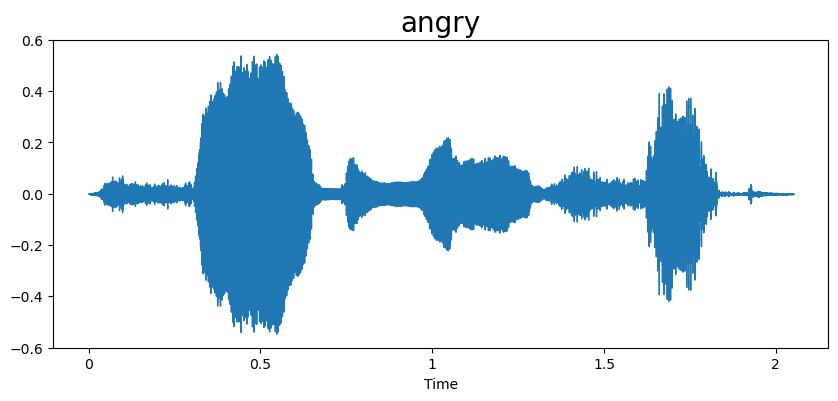

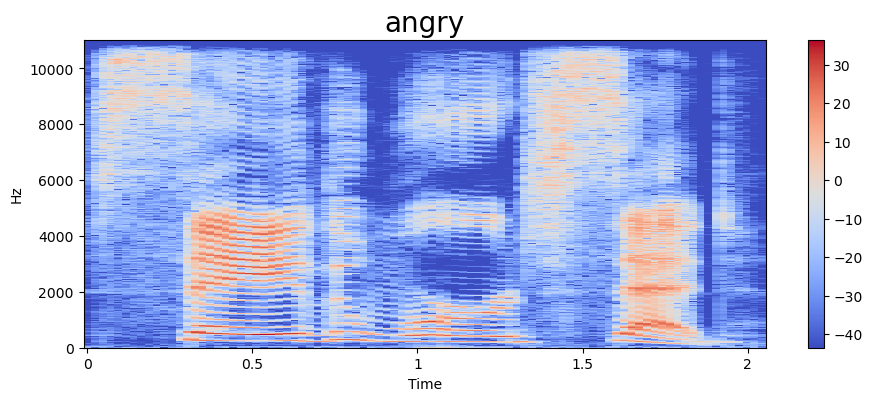

In [266]:
emotion = 'angry'
path = np.array(df['speech'][df['label']==emotion])[1]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

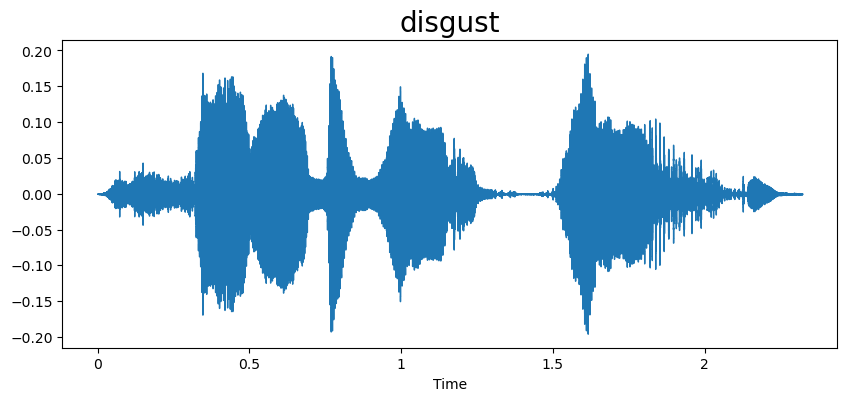

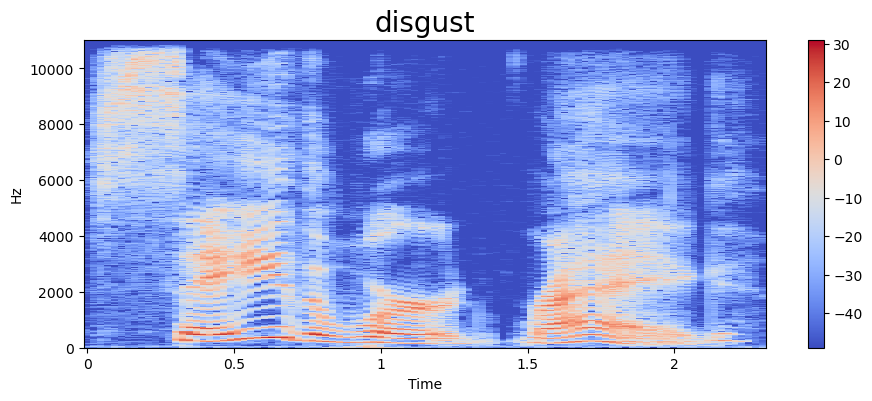

In [267]:
emotion = 'disgust'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

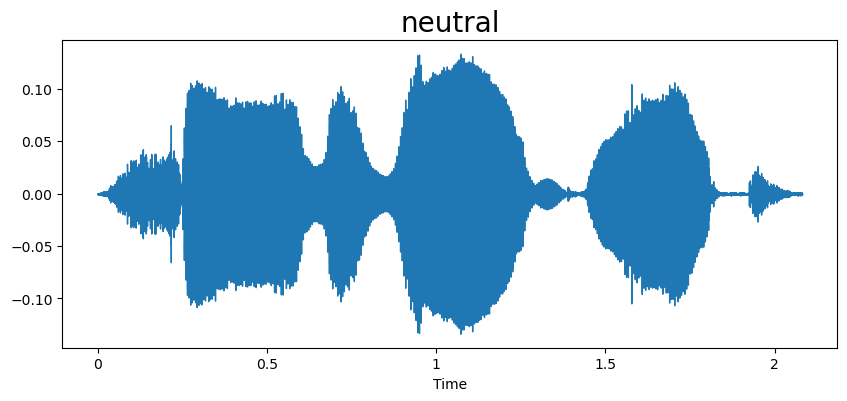

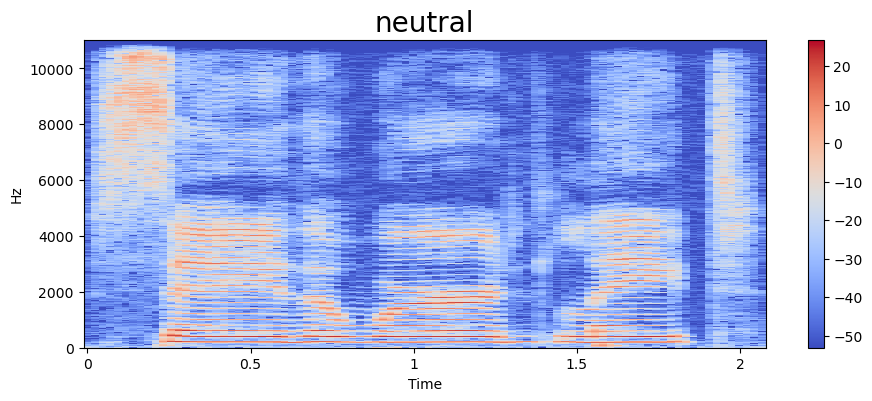

In [268]:
emotion = 'neutral'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

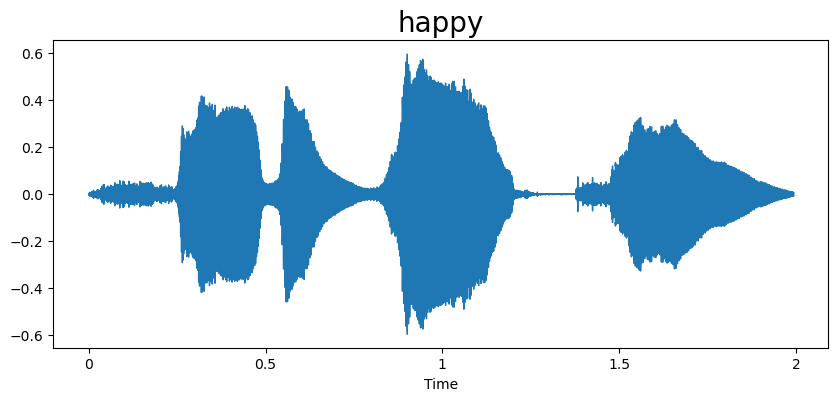

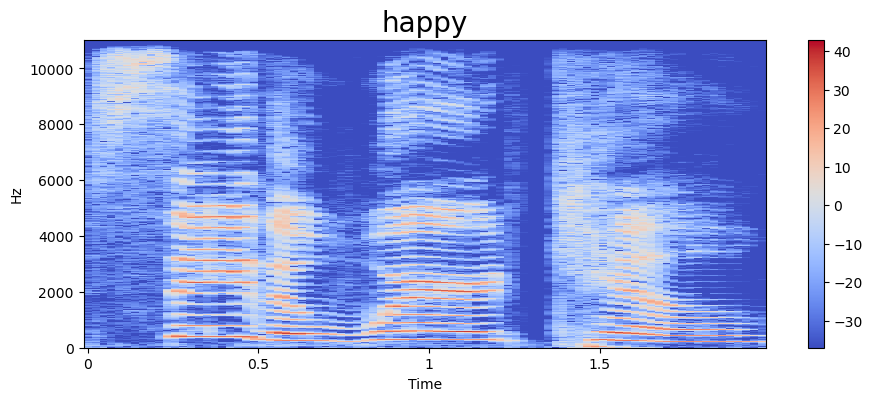

In [269]:
emotion = 'happy'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

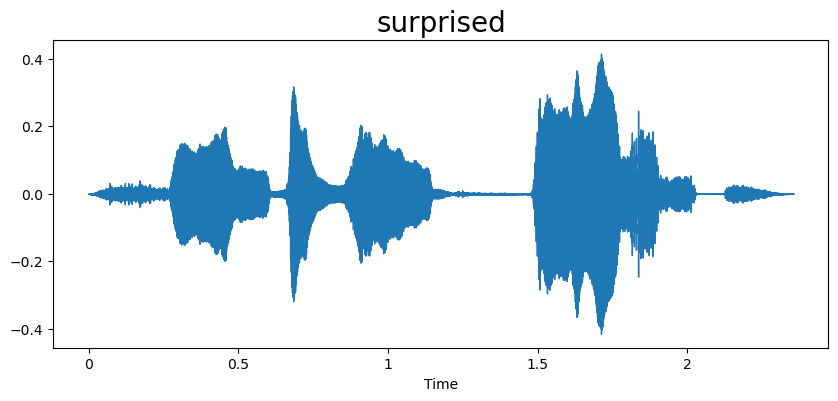

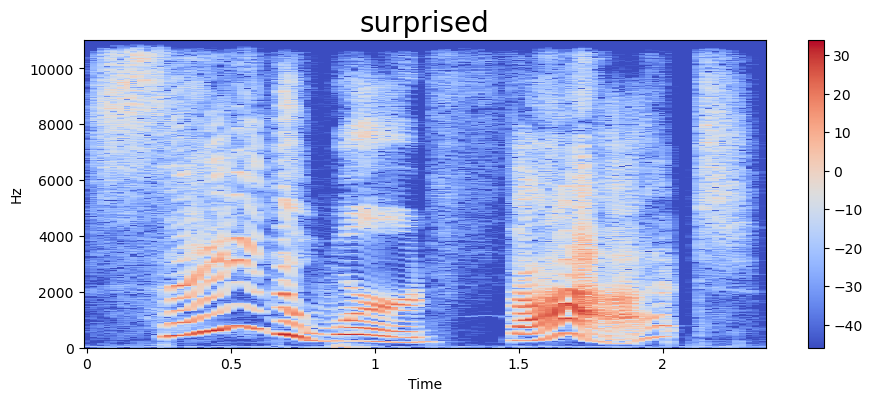

In [270]:
emotion = 'surprised'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

# Feature Extraction 

In [275]:
def extract_mfcc(filename):
    y, sr = librosa.load(filename, duration=3, offset=0.5)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    return mfcc

In [277]:
extract_mfcc(df['speech'][0])

array([-3.2094131e+02,  4.1804806e+01, -2.3261292e+01,  1.0947097e+01,
       -3.2082344e+01,  4.4374447e+00, -2.3038642e+00, -2.2679199e+01,
       -4.9146285e+00, -4.4324412e+00, -1.8578791e+01,  1.3255694e+01,
       -1.4773651e+01,  9.8555956e+00, -3.4038601e+00, -6.5059137e+00,
       -1.0204493e+00,  4.1120523e-01, -2.6993988e+00,  2.5269976e-01,
       -2.5805976e+00,  5.7642292e-02, -1.0413907e+01, -1.0906187e+00,
       -9.7000504e-01,  1.2073672e+00,  4.0025907e+00,  9.7745590e+00,
        1.1407658e+01,  1.3751142e+01,  1.3343264e+01,  9.7866592e+00,
        5.9860430e+00,  8.7844315e+00,  2.0355680e+00,  6.3957763e+00,
        3.7830931e-01,  4.7030749e+00,  7.2897190e-01,  4.3123251e-01],
      dtype=float32)

In [279]:
X_mfcc = df['speech'].apply(lambda x: extract_mfcc(x))

In [281]:
X_mfcc

0     [-320.9413, 41.804806, -23.261292, 10.947097, ...
1     [-312.14984, 29.9573, -3.6903377, 12.131419, -...
2     [-335.5652, 59.73599, 7.289138, 13.05509, -27....
3     [-354.0923, 19.06064, -0.9335696, 16.29313, -2...
4     [-387.82193, 21.266785, 17.25371, 21.870646, -...
                            ...                        
65    [-389.28906, 46.61235, -8.808494, 10.225838, -...
66    [-351.42307, 56.025394, -8.785214, 16.960714, ...
67    [-378.29953, 102.29402, 19.250868, -18.76695, ...
68    [-347.51474, 71.72932, -22.871922, 7.0251765, ...
69    [-398.13113, 56.811985, -2.556549, 4.2016263, ...
Name: speech, Length: 70, dtype: object

In [283]:
X = [x for x in X_mfcc]
X = np.array(X)
X.shape

(70, 40)

In [285]:
#Input Split
X = np.expand_dims(X, -1)
X.shape

(70, 40, 1)

In [287]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
y = enc.fit_transform(df[['label']])

In [289]:
y = y.toarray()

In [291]:
y.shape

(70, 7)